# Exercício:

In [42]:
import pandas as pd
import numpy as np

## 01 – Importe o .csv utilizado no exercício 1 da aula 13 e instancie um objeto da classe DataFrame. Busque no GenBank do NCBI, a sequência aminoacídica referente à cada gene, baixe o arquivo FASTA, e importe para o Python. Instancie um objeto da classe DataFrame onde as linhas serão os genes e as colunas, a sigla, o código de referência e a sequência aminoacídica.

In [23]:
pd.read_csv("df_aula06.csv")
df_uso_excessivo = pd.read_csv("df_aula06.csv")

print(df_uso_excessivo)

    TP53    TNF    IL6   IGF2  BRCA1
0      4      3      3      4      5
1     TP     TN     IL     IG     BR
2      0      0      0      0      1
3  False  False  False  False  False


In [24]:
df_uso_excessivo.T

,0,1,2,3
TP53,4,TP,0,False
TNF,3,TN,0,False
IL6,3,IL,0,False
IGF2,4,IG,0,False
BRCA1,5,BR,1,False


In [25]:
def ler_fasta(caminho):
    with open(caminho, "r") as f:
        linhas = f.readlines()
    
    header = linhas[0].strip()
    sequencia = "".join([linha.strip() for linha in linhas[1:]])
    
    return header, sequencia

In [26]:
genes = ["TP53", "TNF", "IL6", "IGF2", "BRCA1"]

dados = []

for gene in genes:
    header, seq = ler_fasta(f"seq_{gene}.fasta")
    codigo = header.split()[0].replace(">", "")
    dados.append([gene, codigo, seq])

df_final = pd.DataFrame(dados, columns=["Gene", "Código_RefSeq", "Sequência"])

df_final.set_index("Gene", inplace=True)

print(df_final)

      Código_RefSeq                                          Sequência
Gene                                                                  
TP53    NP_000537.3  MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...
TNF     NP_000585.2  MSTESMIRDVELAEEALPKKTGGPQGSRRCLFLSLFSFLIVAGATT...
IL6     NP_000591.1  MNSFSTSAFGPVAFSLGLLLVLPAAFPAPVPPGEDSKDVAAPHRQP...
IGF2    NP_000603.1  MGIPMGKSMLVLLTFLAFASCCIAAYRPSETLCGGELVDTLQFVCG...
BRCA1   NP_009225.1  MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...


## 02 – Importe o .csv as informações dos aminoácidos e instancie um objeto da classe DataFrame. Obtenha a frequência absoluta de cada um dos aminoácidos para cada um dos genes. Instancie um objeto da classe DataFrame com as informações.

In [27]:
frequencias = {}

for gene, linha in df_final.iterrows():
    seq = str(linha["Sequência"])
    
    contagem = {}
    
    for aa in set(seq):
        contagem[aa] = seq.count(aa)
    
    frequencias[gene] = contagem

df_aminoacid = pd.DataFrame.from_dict(frequencias, orient="index").fillna(0)

print(df_aminoacid)

        F   G   R    N   D    S   Y   C    V   Q   P    L    E   M    K    T  \
TP53   11  23  26   14  20   38   9  10   18  15  45   32   30  12   20   22   
TNF    10  17  14    7   7   20   7   4   16  13  15   30   16   2    8   10   
IL6    11   7   9   11   8   19   3   4    8  14  11   28   16   6   14   13   
IGF2   10  12  20    2   7   12   5   8    9   5  15   19   10   4    7   10   
BRCA1  49  87  76  121  85  224  31  44  101  97  96  156  198  30  137  111   

        W   H   I   A  
TP53    4  12   8  24  
TNF     2   4  12  19  
IL6     1   2   9  18  
IGF2    1   3   4  17  
BRCA1  10  49  77  84  


## 03 – Qual é o número de Valinas presentes em cada um dos genes? Qual o gene tem o maior número?

In [28]:
df_aminoacid["V"]
#Gene com maior número = BRCA1

TP53      18
TNF       16
IL6        8
IGF2       9
BRCA1    101
Name: V, dtype: int64

## 04 – Qual a média, a mediana e a moda da frequência absoluta de Serina presente nos genes?

In [29]:
serina = df_aminoacid["S"]

media = serina.mean()
mediana = serina.median()
moda = serina.mode()

print("Média:", media)
print("Mediana:", mediana)
print("Moda:", moda.values)

Média: 62.6
Mediana: 20.0
Moda: [ 12  19  20  38 224]


## 05 – Gere um histograma, contendo a média e a mediana, com o número de Serinas por gene.

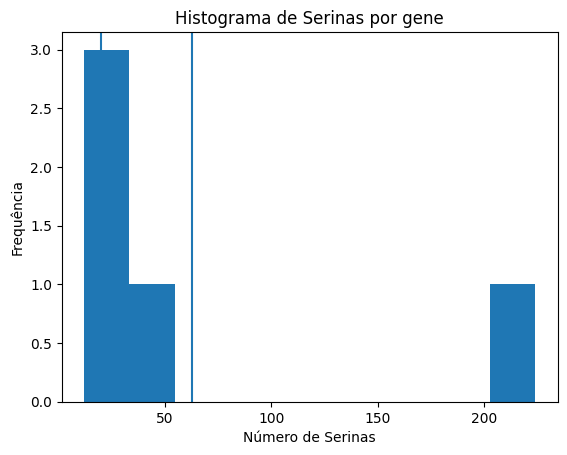

In [30]:
import matplotlib.pyplot as plt

serina = df_final["Sequência"].apply(lambda seq: str(seq).count("S"))

plt.figure()
plt.hist(serina)

plt.axvline(serina.mean())
plt.axvline(serina.median())

plt.title("Histograma de Serinas por gene")
plt.xlabel("Número de Serinas")
plt.ylabel("Frequência")

plt.show()

## 06 – Defina uma função que receba o nome de um aa qualquer e retorne o mesmo resultado do exercício anterior.

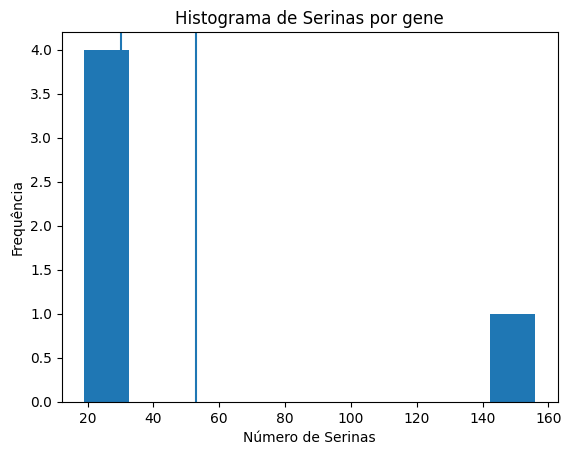

In [34]:
import matplotlib.pyplot as plt

serina = df_final["Sequência"].apply(lambda seq: str(seq).count("L"))

plt.figure()
plt.hist(serina)

plt.axvline(serina.mean())
plt.axvline(serina.median())

plt.title("Histograma de Serinas por gene")
plt.xlabel("Número de Serinas")
plt.ylabel("Frequência")

plt.show()

## 07 – Retorne os gráficos dos aa Glutamina, Glicina, Lisina e Valina. Qual possuí menor diferença entre média e mediana?

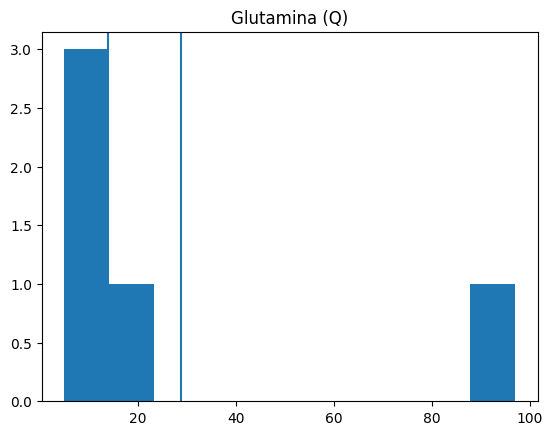

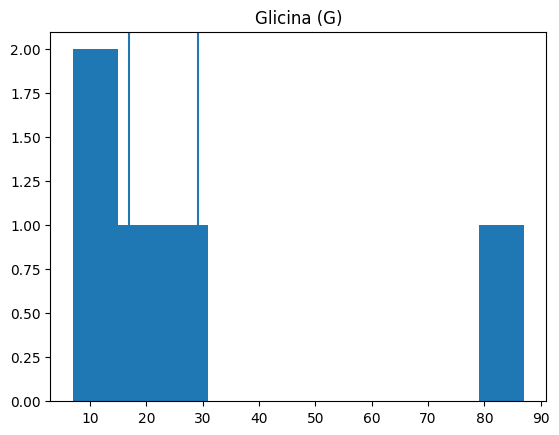

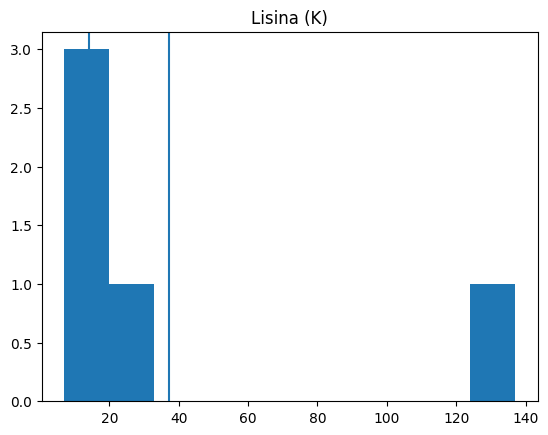

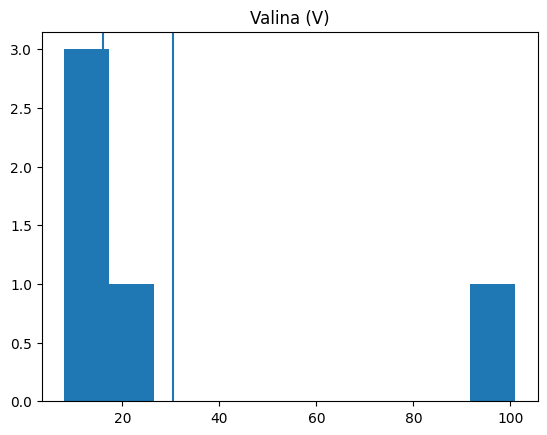

{'Glutamina': np.float64(14.8), 'Glicina': np.float64(12.2), 'Lisina': np.float64(23.200000000000003), 'Valina': np.float64(14.399999999999999)}


In [35]:
import matplotlib.pyplot as plt
import unicodedata

def histograma_por_nome(nome_aminoacido):
    
    nome = unicodedata.normalize('NFKD', nome_aminoacido).encode('ASCII', 'ignore').decode('ASCII').lower()
    
    mapa = {
        "glutamina": "Q",
        "glicina": "G",
        "lisina": "K",
        "valina": "V"
    }
    
    aa = mapa[nome]
    
    contagem = df_final["Sequência"].astype(str).apply(lambda seq: seq.count(aa))
    
    media = contagem.mean()
    mediana = contagem.median()
    
    plt.figure()
    plt.hist(contagem)
    plt.axvline(media)
    plt.axvline(mediana)
    plt.title(f"{nome.capitalize()} ({aa})")
    plt.show()
    
    return media, mediana

resultados = {}

for aa in ["Glutamina", "Glicina", "Lisina", "Valina"]:
    media, mediana = histograma_por_nome(aa)
    resultados[aa] = abs(media - mediana)

print(resultados)

In [36]:
menor = min(resultados, key=resultados.get)
print("Menor diferença:", menor)

Menor diferença: Glicina


## 08 – Dentre os três primeiros genes, qual é a média e a mediana de Cisteína?

In [37]:
subset = df_final.iloc[:3]
cisteina = subset["Sequência"].apply(lambda seq: str(seq).count("C"))

media = cisteina.mean()
mediana = cisteina.median()

print("Média:", media)
print("Mediana:", mediana)

Média: 6.0
Mediana: 4.0


## 09 – Analisando o valor médio de aa em cada um dos genes, qual seria o maior gene (maior número médio de aa)?

In [38]:
tamanho = df_final["Sequência"].apply(lambda seq: len(str(seq)))
maior_gene = tamanho.idxmax()
maior_valor = tamanho.max()

print("Maior gene:", maior_gene)
print("Número de aminoácidos:", maior_valor)

Maior gene: BRCA1
Número de aminoácidos: 1863


## 10 – Olhando o valor médio de aa em cada um dos genes, qual seria o menor gene (menor número médio de aa)?

In [40]:
tamanho = df_final["Sequência"].apply(lambda seq: len(str(seq)))
menor_gene = tamanho.idxmin()
menor_valor = tamanho.min()

print("Menor gene:", menor_gene)
print("Número de aminoácidos:", menor_valor)

Menor gene: IGF2
Número de aminoácidos: 180
